In [1]:
from PIL import Image
import cv2
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from glob import glob
import time
import json
import os

import torch
from torchvision.ops import box_convert
from groundingdino.util.inference import load_model, load_image, predict, annotate

device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. 工具函数

In [2]:
def xyxy_to_xywh(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]
    
    w = x2 - x1
    h = y2 - y1
    return [x1, y1, w, h]

def xyxy_get_area(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]

    w = x2 - x1
    h = y2 - y1
    return w*h

def show_img(img, bboxes = None, tag = None, captions = None):
    '''
        Function: used to show image and corresponding bounding boxes.
    '''
    fig, ax = plt.subplots()
    
    ax.imshow(img)
    
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            if tag is not None:
                ax.text(x, y-8, str(i+1), color='r', fontsize=11, weight='bold')
            if captions is not None:
                ax.text(x+20, y-8, captions[i], color='r', fontsize=11, weight='bold')
    plt.axis("off")
    plt.show()

In [3]:
def load_dino(config, weight, device):
    model = load_model(
        model_config_path = config, 
        model_checkpoint_path=weight,
        device = device
    )
    return model

In [4]:
def dino_processor(model, img_source, img, caption, device, BOX_TRESHOLD = 0.35, TEXT_TRESHOLD = 0.25):

    start_time = time.time()
    boxes, scores, labels = predict(
        model=model,
        image = img,
        caption = caption,
        box_threshold = BOX_TRESHOLD,
        text_threshold= TEXT_TRESHOLD,
        device = device
    )
    inference_time = time.time() - start_time
    
    h, w, _ = img_source.shape
    bboxes = box_convert(
        boxes=boxes * torch.Tensor([w, h, w, h]), 
        in_fmt="cxcywh", 
        out_fmt="xyxy"
    ).numpy().tolist()
    areas = [xyxy_get_area(bbox) for bbox in bboxes]
    
    scores = scores.tolist()

    result = []
    for bbox, area, label, score in zip(bboxes, areas, labels, scores):
        result.append({
            "bbox":xyxy_to_xywh(np.array(bbox).astype(np.int64).tolist()),
            "area":xyxy_get_area(bbox),
            "label":label,
            "score":score
        })

    return result, [w, h], inference_time

## 2. Dino模型推断

In [5]:
config = "./vgms/dino/configs/GroundingDINO_SwinT_OGC.py"
weight = "./vgms/dino/weights/groundingdino_swint_ogc.pth"
model = load_dino(config = config, weight = weight, device = device)

# dino是对单复数敏感的。cylinder 只会获取一个bbox；cylinders 会获取所有的bbox.
caption = "excavator . truck ."

img_path_list = glob("./imgs/dataset/5. vehicle/*/*.jpg")
img_outcome = {}

final text_encoder_type: bert-base-uncased


In [6]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


def draw_bboxes_and_show(image_path, bboxes, color="red", width=3):
    """
    读取图片路径，在图片上绘制多个 bbox，并使用 matplotlib 显示。

    参数:
        image_path (str): 图片路径
        bboxes (list): [(x, y, w, h), ...]
        color (str or list): 单一颜色 or 每个 bbox 对应的颜色列表
        width (int): 边框线宽

    返回:
        PIL.Image.Image: 绘制了 bbox 的图片
    """
    image = Image.open(image_path).convert("RGB")
    image_with_bbox = image.copy()
    draw = ImageDraw.Draw(image_with_bbox)

    # 如果是单一颜色，扩展成列表
    if isinstance(color, str):
        colors = [color] * len(bboxes)
    else:
        colors = color

    for bbox, c in zip(bboxes, colors):
        if len(bbox) != 4:
            raise ValueError("每个 bbox 必须是 (x, y, w, h) 格式")

        x, y, w, h = bbox
        x1, y1 = x, y
        x2, y2 = x + w, y + h

        draw.rectangle([x1, y1, x2, y2], outline=c, width=width)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_with_bbox)
    plt.axis("off")
    plt.show()

    return image_with_bbox

In [17]:
caption = "gas cylinders ."
img_path = "./imgs/dataset/1. gas cylinder/1_41.jpg"
image_source, image = load_image(img_path)
outcome, image_size, inference_time = dino_processor(
        model = model, 
        img_source = image_source, 
        img = image, 
        caption = caption, 
        device = device, 
        BOX_TRESHOLD = 0.35, 
        TEXT_TRESHOLD = 0.25
    )

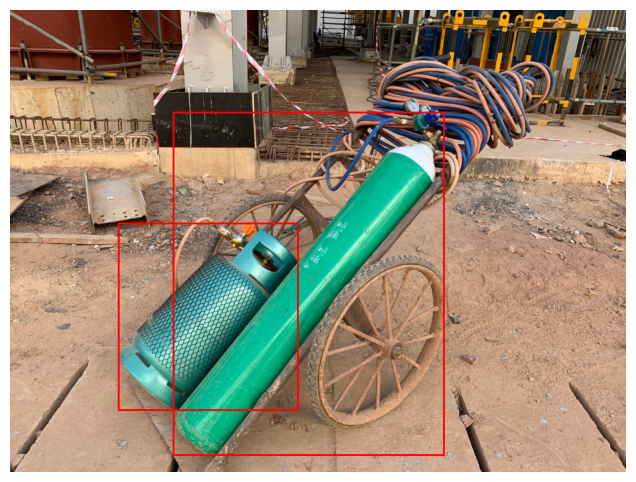

In [18]:
bboxes = [r["bbox"] for r in outcome]
image_with_bbox = draw_bboxes_and_show(image_path=img_path, bboxes=bboxes)
image_with_bbox.save(f"./imgs/results/groundingDINO_1.jpg")

In [55]:
img_based_root = "./imgs/dataset/5. vehicle/"
img_path = os.path.join(img_based_root, "5_1_124.jpg")
img = Image.open(img_path)
image_source, image = load_image(img_path)
outcome, image_size, inference_time = dino_processor(
        model = model, 
        img_source = image_source, 
        img = image, 
        caption = caption, 
        device = device, 
        BOX_TRESHOLD = 0.35, 
        TEXT_TRESHOLD = 0.25
    )
print(outcome)

[{'bbox': [18, 53, 1810, 820], 'area': 1484276.6778903715, 'label': 'excavator', 'score': 0.6888967752456665}, {'bbox': [0, 347, 212, 208], 'area': 43999.5769761689, 'label': 'truck', 'score': 0.3968387544155121}, {'bbox': [541, 383, 589, 283], 'area': 166312.3148649633, 'label': 'truck', 'score': 0.4035782217979431}]


In [56]:
bboxes = [bboxInfo["bbox"] for bboxInfo in outcome ] #if "excavator" in bboxInfo["label"]

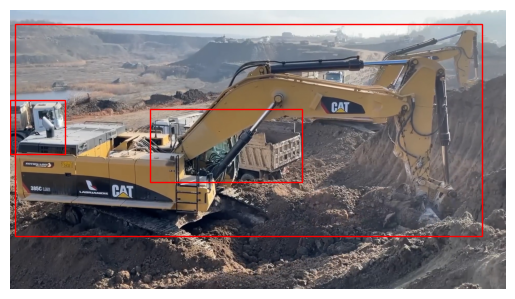

In [57]:
show_img(img, bboxes)

In [8]:
i = 0
for img_path in tqdm(img_path_list):
    image_source, image = load_image(img_path)
    
    outcome, image_size, inference_time = dino_processor(
        model = model, 
        img_source = image_source, 
        img = image, 
        caption = caption, 
        device = device, 
        BOX_TRESHOLD = 0.35, 
        TEXT_TRESHOLD = 0.25
    )

    img_outcome[i] = {
        "img_path":img_path,
        "img_size":image_size, #[width, height]
        "inference_time":inference_time,
        "result":outcome
    }
    
    i += 1

100%|████████████████████████████████████████████████████████████████████████████████| 837/837 [11:08<00:00,  1.25it/s]


In [9]:
with open(f"./results/dino_{5}_2.json", "w") as fp:
    fp.write(json.dumps(img_outcome))

## 3. 测试代码

In [64]:
# model = load_model(
#     model_config_path = "./vgms/dino/configs/GroundingDINO_SwinT_OGC.py", 
#     model_checkpoint_path = "./vgms/dino/weights/groundingdino_swint_ogc.pth",
#     device=device
# )

In [65]:
# IMAGE_PATH = "./imgs/testing.jpg"
# image_source, image = load_image(IMAGE_PATH)

# caption = "cylinders . tanks ."
# BOX_TRESHOLD = 0.35
# TEXT_TRESHOLD = 0.25

# boxes, scores, labels = predict(
#     model=model,
#     image = image,
#     caption=caption,
#     box_threshold = BOX_TRESHOLD,
#     text_threshold= TEXT_TRESHOLD,
#     device = device
# )